In [1]:
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from typing import TypedDict, Any

d:\genai\venv\lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [9]:
#define state 
class GraphState:
    weight: float
    height: float
    bmi: float


In [10]:
def get_bmi(state : GraphState)->GraphState:
    weight = state['weight']
    height = state['height']
    bmi= weight /(height**2)
    state['bmi']=round(bmi,2)
    return state

In [11]:
##define the graph
graph = StateGraph(GraphState)
##add node 
graph.add_node("calculate_bmi",get_bmi)
##add edges 
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi",END)
## compile graph
workflow = graph.compile()

In [16]:
initial_state = {'weight': 70, 'height': 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86}


In [17]:
class BlogState:
    title : str
    outline : str
    content : str

In [68]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY", "")
os.environ["GOOGLE_CSE_ID"] = os.getenv("GOOGLE_CSE_ID", "")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY", "")
os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING", "")

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [48]:
def get_outline(state : BlogState)->BlogState:
    title=state['title']
    prompt = ChatPromptTemplate.from_messages([
        ("system","You are a helpful assistant that creates outlines for blogs"),
        ("human",f"Create an outline for a blog with the title {title}")
    ])
    messages = prompt.format_messages()
    outline = llm.invoke(messages)
    state['outline']=outline.content
    return state

In [45]:
def get_content(state: BlogState)->BlogState:
    outline = state['outline']
    title = state['title']
    prompt = ChatPromptTemplate.from_messages([
        ("system","You are a helpful assistant that creates content for blogs based on the outline"),
        ("human",f"Create content for a blog titled {title} with the following outline {outline}")
    ])
    messages = prompt.format_messages()
    content = llm.invoke(messages)
    state['content']=content.content
    return state

In [49]:
graph = StateGraph(BlogState)
## adding the graph node 
graph.add_node("create_outline",get_outline)
graph.add_node("create_blog",get_content)
##adding the edges 
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)
workflow= graph.compile()
 

In [47]:
initial_state = {'title': "Recent Advancement of AI in 2026 software dev industry"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Recent Advancement of AI in 2026 software dev industry', 'outline': 'Here\'s a detailed outline for a blog post titled "Recent Advancement of AI in 2026 Software Dev Industry," focusing on a forward-looking yet realistic perspective.\n\n---\n\n## Blog Post Outline: Recent Advancement of AI in 2026 Software Dev Industry\n\n**Title:** Recent Advancement of AI in 2026 Software Dev Industry\n\n**Target Audience:** Software developers, engineering managers, CTOs, tech enthusiasts, product owners.\n\n**Goal:** To inform readers about the significant, practical ways AI is expected to be integrated into and transform the software development lifecycle by 2026.\n\n---\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Hook:** Start with the rapid, undeniable acceleration of AI\'s impact on every industry, particularly software development.\n*   **B. Current State (Brief):** Briefly acknowledge the current AI tools (e.g., GitHub Copilot, intelligent IDEs) as foundational.\n*  

In [50]:
class aLLM: 
    def __init__(self):
         print('LLM created')
    def predict(self,prompt):
        response_list=[
            'response1',
            'response2'
        ]
        return {"response":random.choice(response_list)}

In [52]:
llm = aLLM()

LLM created


In [54]:
class bLLM:
    def __init__(self,template,input):
        self.template= template
        self.input=input
    def format(self,input_dict):
        return self.template.format(**input_dict)
        

In [55]:
from abc import ABC, abstractmethod
class Runnable(ABC):
    @abstractmethod
    def invoke(input_data):
        pass

In [56]:
class nLLM(Runnable): 
    def __init__(self):
         print('LLM created')
    def invoke(self,prompt):
        response_list=[
            'response1',
            'response2'
        ]
        return {"response":random.choice(response_list)} 
    def predict(self,prompt):
        response_list=[
            'response1',
            'response2'
        ]
        return {"response":random.choice(response_list)}

In [57]:
class tLLM(Runnable):
    def __init__(self,template,input):
        self.template= template
        self.input=input
    
    def invoke(self,input_dict):
        return self.template.format(**input_dict)
    def format(self,input_dict):
        return self.template.format(**input_dict)

In [58]:
class Chaining(Runnable):
    def __init__(self, *runnables):
        self.runnables = runnables
    
    def invoke(self, input_data):
        for runnable in self.runnables:
            input_data = runnable.invoke(input_data)
        return input_data

In [11]:
##Pararell workflow in langgraph
from pydantic import BaseModel,Field
class BatsmanState(BaseModel):
    runs : int = Field(0, description="Number of runs scored by the batsman")
    balls : int = Field(0, description="Number of balls played by the batsman")
    four : int = Field(0, decription = "Number of fours scored by the batsman")
    six : int = Field(0,description="Number of sixes scored by the batsman")
    bpb: float =Field(0.0,description="Number of boundaries per boundaries")
    boundary_percent : float = Field(0.0, description ="Percentage of runs in boundaries scored by the batsman")
    strike_rate: int = Field(0,description = "Strike rate of the batsman")
    summary : str = Field(...,description = "Summary of batsman performance")
    


C:\Users\soupt\AppData\Local\Temp\ipykernel_13456\470143395.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'decription'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  four : int = Field(0, decription = "Number of fours scored by the batsman")


In [22]:
def calculate_sr(state: BatsmanState):
    sr=state['runs']/state['balls']/100
    state['strike_rate']=sr
    return {'sr':sr}

In [23]:
def calculate_bpb(state : BatsmanState):
   bpb =  state['balls']/(state['fours']+state['six'])
   state['bpb']=bpb
   return {'bpb':bpb}

In [24]:
def calculate_boundary_percent(state:BatsmanState):
    boundary_percent = (state['fours']*4 + state['six']*6)/state['runs']*100
    state['boundary_percent']=boundary_percent
    return {'boundary_percent':boundary_percent}

In [25]:
def calculate_summary(state : BatsmanState):
    summary = f"""
      Strike Rate - {state['strike_rate']}
      Balls per boundary- {state['bpb']}
      Boundary Percentage - {state['boundary_percent']}
    """
    state['summary']=summary
    return state
      

In [20]:
graph = StateGraph(BatsmanState)
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('calculate_summary',calculate_summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')
graph.add_edge('calculate_boundary_percent','calculate_summary')
graph.add_edge('calculate_bpb','calculate_summary')
graph.add_edge('calculate_sr','calculate_summary')
graph.add_edge('calculate_summary',END)
workflow= graph.compile()

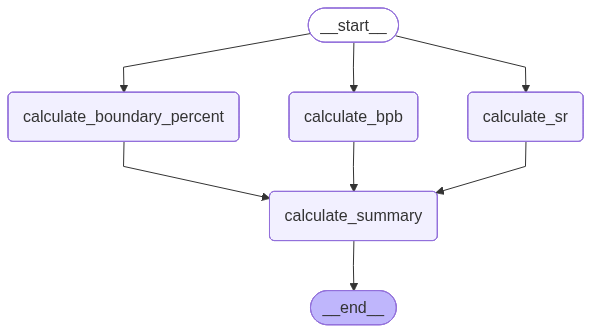

In [21]:
workflow

In [ ]:
initial_state = {
    "runs": 72,
    "balls": 49,
    "four": 8,
    "six": 2,
    "bpb": 0.0,
    "boundary_percent": 0.0,
    "strike_rate": 0.0,
    "summary": ""
}
final_state= workflow.invoke(initial_state)
final_state

In [5]:
from pydantic import BaseModel,Field
class EvaluationSchema(BaseModel):
    feedback: str = Field(...,description="Detailed feedback for essay")
    score: int =Field(...,description="Score out of 10",ge=0 , le=10)

In [7]:
llm_structured_output=llm.with_structured_output(EvaluationSchema)

In [8]:
essay = """
     The Importance of Urban Green Spaces
Urbanization is rapidly transforming the global landscape, drawing millions of people into densely populated cities. While this shift drives economic growth and innovation, it also presents significant challenges to public health and environmental sustainability. In this context, urban green spaces—such as parks, botanical gardens, and tree-lined streets—have emerged as essential components of modern city planning.
Primarily, green spaces serve as vital ecological lungs for urban environments. They mitigate the "urban heat island" effect by providing shade and cooling the air through evapotranspiration. Furthermore, vegetation acts as a natural air filter, absorbing pollutants and carbon dioxide while releasing oxygen. This ecological function is critical for combating climate change and improving the overall air quality for city residents.
Beyond environmental benefits, urban parks profoundly impact psychological well-being. The relentless pace, noise, and concrete aesthetics of city life can contribute to chronic stress and anxiety. Green spaces offer a necessary sanctuary for relaxation and recreation. Studies consistently show that spending time in nature reduces cortisol levels and enhances cognitive function. These areas also foster community cohesion by providing shared public squares where people from diverse backgrounds can interact, exercise, and host cultural events.
In conclusion, integrating nature into urban infrastructure is not merely an aesthetic luxury but a fundamental necessity. As cities continue to expand, prioritizing the development and maintenance of green spaces will be crucial for creating sustainable, resilient, and livable environments for future generations.
"""

In [10]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
llm_structured_output.invoke(prompt).score

9

In [11]:
import operator
from typing import Annotated, TypedDict, List # 'list' is fine in Python 3.9+

class EssayState(TypedDict):
    """
    State representing the essay and its various feedback metrics.
    """
    essay: str                  # Essay content
    language_feedback: str      # Language feedback
    analysis_feedback: str      # Analysis feedback of the essay
    clarity_feedback: str       # Clarity analysis of the essay
    overall_feedback: str       # Overall feedback of the essay
    individual_scores: Annotated[list[int],operator.add] # List of scores of differen    

In [30]:
def eval_lang(state : EssayState):
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = llm_structured_output.invoke(prompt)
    
    return {"language_feedback": output.feedback,'individual_scores': [output.score]}
    


In [31]:
def eval_analysis(state : EssayState):
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = llm_structured_output.invoke(prompt)
    
    return {"analysis_feedback": output.feedback,'individual_scores': [output.score]}


In [32]:
def eval_thought(state : EssayState):
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = llm_structured_output.invoke(prompt)
    
    return {"clarity_feedback": output.feedback,'individual_scores': [output.score]}


In [33]:
def final_evaluation(state: EssayState):
    #summary feedback overall
    prompt = f'Based on the foolowing feedback summary \n language feedback - {state["language_feedback"]} \n Analysis feedback - {state["analysis_feedback"]} \n Clarity of thought - {state["clarity_feedback"]}'
    overall_feedback=llm_structured_output.invoke(prompt).feedback
    #avg calculation of all the scores 
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {"overall_feedback":overall_feedback,"avg_score":avg_score}
    

In [34]:
graph = StateGraph(EssayState)
graph.add_node('eval_lang',eval_lang)
graph.add_node('eval_analysis',eval_analysis)
graph.add_node('eval_thought',eval_thought)
graph.add_node('final_evaluation',final_evaluation)
graph.add_edge(START,'eval_lang')
graph.add_edge(START,'eval_analysis')
graph.add_edge(START,'eval_thought')
graph.add_edge('eval_lang','final_evaluation')
graph.add_edge('eval_analysis','final_evaluation')
graph.add_edge('eval_thought','final_evaluation')
graph.add_edge('final_evaluation',END)
workflow = graph.compile()

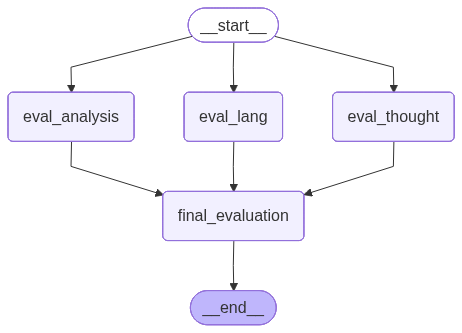

In [35]:
workflow

In [36]:
initial_state = {
    "essay": {essay}
    }
final_state = workflow.invoke(initial_state)
print(final_state)

{'essay': {'\n     The Importance of Urban Green Spaces\n\nUrbanization is rapidly transforming the global landscape, drawing millions of people into densely populated cities. While this shift drives economic growth and innovation, it also presents significant challenges to public health and environmental sustainability. In this context, urban green spaces—such as parks, botanical gardens, and tree-lined streets—have emerged as essential components of modern city planning.\n\nPrimarily, green spaces serve as vital ecological lungs for urban environments. They mitigate the "urban heat island" effect by providing shade and cooling the air through evapotranspiration. Furthermore, vegetation acts as a natural air filter, absorbing pollutants and carbon dioxide while releasing oxygen. This ecological function is critical for combating climate change and improving the overall air quality for city residents.\n\nBeyond environmental benefits, urban parks profoundly impact psychological well-be

In [37]:
generator_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5)
evaluator_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5)
optimizer_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5)


In [42]:
#State
from typing import Literal


class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved','needs_improvement']
    feedback: str
    iterations : int
    max_iterations : int
    
    tweet_history: Annotated[List[str],operator.add]
    feedback_history: Annotated[List[str],operator.add]


In [40]:
from pydantic import BaseModel, Field
class TweetEvaluation(BaseModel):
    feedback: str = Field(...,description="Detailed feedback for the tweet")
    evaluation: Literal['approved','needs_improvement'] = Field(...,description="Evaluation of the tweet")

In [41]:
evaluator_llm_structured_output = evaluator_llm.with_structured_output(TweetEvaluation)

In [45]:
def generate_tweet(state: TweetState)->TweetState:
    prompt = f'Generate a creative and engaging tweet on the topic {state["topic"]}'
    output = generator_llm.invoke(prompt)
    state['tweet']=output.content
    return {'tweet':output.content,'tweet_history':[output.content]}

def evaluate_tweet(state: TweetState)->TweetState:
    #prompt for evaluation
    prompt = f"""
      Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?  
2. Humor - Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness - Is it short, sharp, and scroll-stopping?  
4. Virality Potential - Would people retweet or share it?  
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
    """
    output = evaluator_llm_structured_output.invoke(prompt)
    return {'evaluation': output.evaluation,'feedback': output.feedback,'feedback_history':[output.feedback],'tweet_history': state['tweet_history']}

In [44]:
def optimize_tweet(state: TweetState)->TweetState:
    prompt = f"""
      Optimize the following tweet based on the feedback provided:
      
      Tweet: "{state['tweet']}"

      Feedback: "{state['feedback']}"
    """
    output = generator_llm.invoke(prompt)
    iteration = state['iterations'] + 1 
    return {'tweet': output.content, 'tweet_history': state['tweet_history'] + [output.content], 'iterations': iteration}

In [47]:
def route_evaluator(state: TweetState)->str:
    if state['evaluation']=='approved' or state['iterations']>=state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

In [48]:
graph = StateGraph(TweetState)
graph.add_node('generate_tweet',generate_tweet)
graph.add_node('evaluate_tweet',evaluate_tweet)
graph.add_node('optimize_tweet',optimize_tweet)

graph.add_edge(START,'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet',route_evaluator,{'approved':END,'needs_improvement':'optimize_tweet'})
graph.add_edge('optimize_tweet','evaluate_tweet')
workflow = graph.compile()


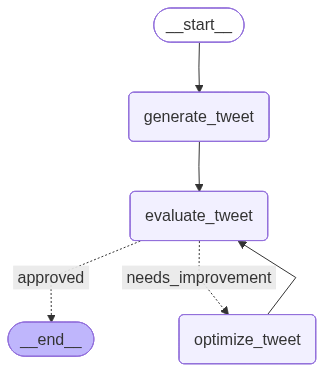

In [49]:
workflow

In [ ]:
initial_state={
    "topic": "The importance of mental health awareness",
    "iterations": 1,
    "max_iterations": 3
}
result = workflow.invoke(initial_state)
print(result)

In [74]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict, Annotated, List
from langgraph.checkpoint.memory import InMemorySaver

In [75]:
class JokeState(TypedDict):
    topic: str 
    joke: str
    explaination: str

In [76]:
def generate_joke(state: JokeState):
    prompt=f"generate a joke on the topic {state['topic']}"
    response= llm.invoke(prompt)
    return {'joke':response.content}
def generate_explaination(state:JokeState):
    prompt=f"explain the joke {state['joke']} in simple terms"
    response= llm.invoke(prompt)
    return {'explaination':response.content}

In [77]:
graph = StateGraph(JokeState)
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explaination',generate_explaination)
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explaination')
graph.add_edge('generate_explaination',END)
checkpointer= InMemorySaver()
workflow= graph.compile(checkpointer=checkpointer) 

In [78]:
config = {"configurable":{"thread_id":"1"}}
workflow.invoke({"topic":"Pizza"},config=config)

{'topic': 'Pizza',
 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!',
 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\nIt\'s funny because i

In [79]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!', 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\nI

In [80]:
workflow.invoke(None,config)

{'topic': 'Pizza',
 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!',
 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\nIt\'s funny because i

In [82]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!', 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\nI

In [83]:
config2={"configurable":{"thread_id":"2"}}
workflow.invoke({"topic":"Technology"},config=config2)

{'topic': 'Technology',
 'joke': "Why did the Wi-Fi break up with the internet service provider?\nBecause they just weren't **connecting** anymore!",
 'explaination': 'This joke works because of a **double meaning** of the word "connecting":\n\n1.  **For Wi-Fi (technical meaning):** When your Wi-Fi isn\'t "connecting," it means it\'s not linking up to the internet, so you can\'t get online. It\'s a technical problem.\n\n2.  **For people in a relationship (human meaning):** When people aren\'t "connecting," it means they don\'t understand each other, they\'re not getting along, or their relationship is falling apart.\n\nThe joke pretends Wi-Fi and the internet service provider are like two people breaking up. The punchline uses "connecting" to sound like a human relationship problem (they don\'t get along anymore), but it\'s also the literal technical problem when your Wi-Fi doesn\'t work!\n\nSo, it\'s funny because it uses a tech problem to sound like a human relationship problem.'}

In [84]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!', 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\nIt

In [85]:
workflow.update_state(config,{"topic":"samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1503c1-b248-6086-8003-b4d55627215d'}}

In [86]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!', 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\n

In [87]:
workflow.invoke(None,config=config)

{'topic': 'samosa',
 'joke': 'Why did the pizza maker break up with the cheese?\n\nBecause he thought it was too *cheesy*!',
 'explaination': 'This is a classic "pun" joke, which means it plays on the different meanings of a word.\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning of "Cheesy":** When you talk about food, "cheesy" means something is made of cheese or has a lot of cheese. This is the obvious meaning when talking about a pizza maker and cheese.\n\n2.  **Slang Meaning of "Cheesy":** In everyday language, "cheesy" also means something is:\n    *   Silly or a bit cringey.\n    *   Not cool or original.\n    *   Overly sentimental or dramatic in a bad way.\n    *   Like a bad joke or a corny pick-up line.\n\n**The Joke:**\n\nThe joke pretends that the pizza maker broke up with the cheese not because of its literal cheesiness (which is its job!), but because he thought it was "cheesy" in the **slang sense** – meaning he found it silly, corny, or uncool.\n\nIt\'s funny because 

In [88]:
try:
  config4 = {"configurable":{"thread_id":"4"}}
  workflow.invoke({'topic':"Cricket"},config=config4)
except Exception as e:
    print("Terminated")

KeyboardInterrupt: 

In [89]:
final_state = workflow.invoke(None,config=config4)
print(final_state)

{'topic': 'Cricket', 'joke': 'Why did the snail get a job as a cricket umpire?\nBecause he was used to things moving at his pace!', 'explaination': 'This joke plays on two main ideas:\n\n1.  **Snails are incredibly slow.** That\'s their most famous characteristic.\n2.  **The word "pace"** has two meanings here:\n    *   A snail\'s literal speed ("his pace").\n    *   The speed or rhythm of a game or activity (the "pace" of cricket).\n\n**Here\'s the simple explanation:**\n\nThe joke is funny because it suggests that a snail, being naturally **super slow**, would be a perfect cricket umpire. Why? Because the job (watching a cricket game, which can sometimes have long periods of waiting between actions) would feel perfectly normal to the snail, who is "used to things moving at his pace" – meaning, **very, very slowly!**\n\nIt\'s a silly way of saying that a snail\'s slowness, which would be a disadvantage in most jobs, would actually be an advantage or at least a comfortable fit for the 

In [90]:
list(workflow.get_state_history(config4))

[StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the snail get a job as a cricket umpire?\nBecause he was used to things moving at his pace!', 'explaination': 'This joke plays on two main ideas:\n\n1.  **Snails are incredibly slow.** That\'s their most famous characteristic.\n2.  **The word "pace"** has two meanings here:\n    *   A snail\'s literal speed ("his pace").\n    *   The speed or rhythm of a game or activity (the "pace" of cricket).\n\n**Here\'s the simple explanation:**\n\nThe joke is funny because it suggests that a snail, being naturally **super slow**, would be a perfect cricket umpire. Why? Because the job (watching a cricket game, which can sometimes have long periods of waiting between actions) would feel perfectly normal to the snail, who is "used to things moving at his pace" – meaning, **very, very slowly!**\n\nIt\'s a silly way of saying that a snail\'s slowness, which would be a disadvantage in most jobs, would actually be an advantage or at least a co

In [93]:
workflow.get_state(config4)

StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the snail get a job as a cricket umpire?\nBecause he was used to things moving at his pace!', 'explaination': 'This joke plays on two main ideas:\n\n1.  **Snails are incredibly slow.** That\'s their most famous characteristic.\n2.  **The word "pace"** has two meanings here:\n    *   A snail\'s literal speed ("his pace").\n    *   The speed or rhythm of a game or activity (the "pace" of cricket).\n\n**Here\'s the simple explanation:**\n\nThe joke is funny because it suggests that a snail, being naturally **super slow**, would be a perfect cricket umpire. Why? Because the job (watching a cricket game, which can sometimes have long periods of waiting between actions) would feel perfectly normal to the snail, who is "used to things moving at his pace" – meaning, **very, very slowly!**\n\nIt\'s a silly way of saying that a snail\'s slowness, which would be a disadvantage in most jobs, would actually be an advantage or at least a com

In [104]:
from langchain_core.tools import tool
import requests
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [105]:
tools=[get_stock_price,calculator]
llm_with_tools = llm.bind_tools(tools)

In [106]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    topic: str
    messages: Annotated[List[BaseMessage],operator.add]

In [107]:
from langgraph.prebuilt import ToolNode


def chat_node(state: ChatState)->ChatState:
    """ LLM node that may answer or reuest a tool call"""
    messages= state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages":[response]}
tool_node = ToolNode(tools)

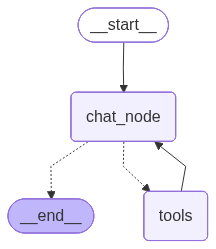

In [108]:
from langgraph.prebuilt import tools_condition


graph = StateGraph(ChatState)
graph.add_node('chat_node',chat_node)
graph.add_node("tools",tool_node)
graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")
workflow=graph.compile()
workflow

In [109]:
out=workflow.invoke({"topic":"stock price of AAPL","messages":[HumanMessage(content="What is the stock price of AAPL?")]})
print(out)

{'topic': 'stock price of AAPL', 'messages': [HumanMessage(content='What is the stock price of AAPL?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "AAPL"}'}, '__gemini_function_call_thought_signatures__': {'ff6d8e90-3a17-452f-946c-c5d6b485f5bf': 'CuIBAQw51scwGO33qlXM4bxKd/9/Nz1bUK0wNJ5nLKdFBizU6Fy8xSn+6axlvvKDJamOKobG9Bd4FQ5VYD85UBK9WSFnM020x6n1yPMUUal7HlOJm+EU9QWmKrZ5okAbTE1t+RJO1Bu2kGdxs61GXGlQM6G/q42e6igiteRVHMvqfNLVLvVKgnACYmtYf8asC5fiAHA8uEzPM8QWGPo1aUOLVvIr37kAQRDcaIZzp99fGSnw2GR1sX+IJJumV0DlJLjg0PpQ7BmhlUwNTrqHSK80Y9km6/27ch5ljsp9c9bncJo4/g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e2b19-f28b-7661-8b6b-5e5e1e484b69-0', tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'AAPL'}, 'id': 'ff6d8e90-3a17-452f-946c-c5d6b485f5bf', 'type': 'tool_call'}], inv

In [110]:
out["messages"][-1].content

'The stock price of AAPL is $298.21.'

In [111]:
import sqlite3